#### Problem Statement: Develop a machine learning classification model that can predict the customer/wine segment based on the chemical properties of wine. The objective is to analyze the relationship between different chemical characteristics and customer segments, and build a Gradient Boosting model capable of accurately classifying new wine samples into the appropriate segment.

#### Import libraries and dataset 

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [58]:
df=pd.read_csv(r"Wine.csv")
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


#### Understand the dataset

In [59]:
df.shape

(178, 14)

In [60]:
df.dtypes

Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Ash_Alcanity            float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280                   float64
Proline                   int64
Customer_Segment          int64
dtype: object

In [61]:
df.isna().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
Customer_Segment        0
dtype: int64

In [62]:
df.duplicated().sum()

np.int64(0)

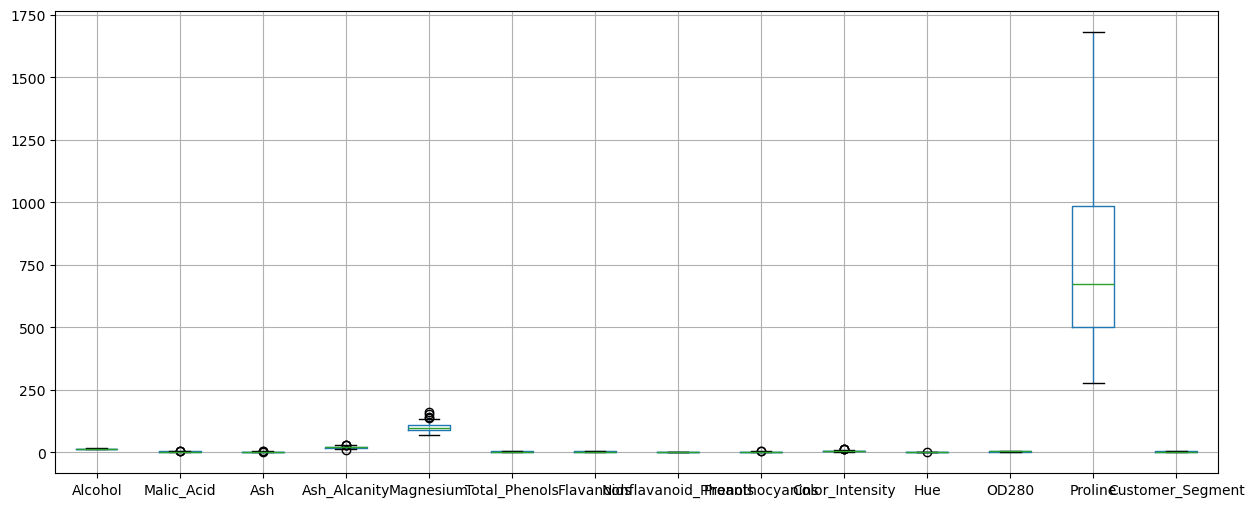

In [63]:
plt.figure(figsize=(15,6))
df.boxplot()
plt.show()

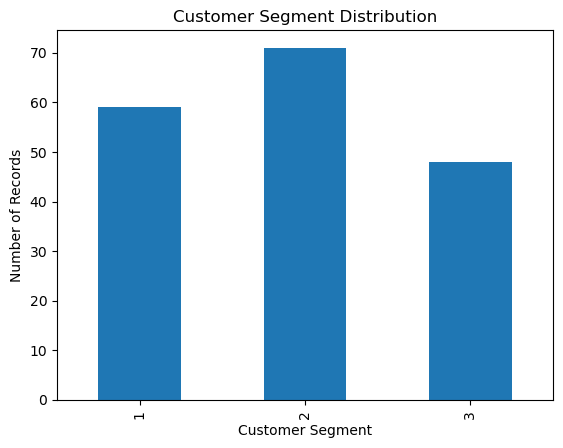

In [64]:


df["Customer_Segment"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Customer Segment")
plt.ylabel("Number of Records")
plt.title("Customer Segment Distribution")
plt.show()

##### The target contains three classes and there is no severe class imbalance.
##### We don't need SMOTE or ADASYN for this dataset.

#### Find the correlation between the chemical properties

Flavanoids             -0.847498
OD280                  -0.788230
Total_Phenols          -0.719163
Proline                -0.633717
Hue                    -0.617369
Ash_Alcanity            0.517859
Proanthocyanins        -0.499130
Nonflavanoid_Phenols    0.489109
Malic_Acid              0.437776
Alcohol                -0.328222
Color_Intensity         0.265668
Magnesium              -0.209179
Ash                    -0.049643
Name: Customer_Segment, dtype: float64


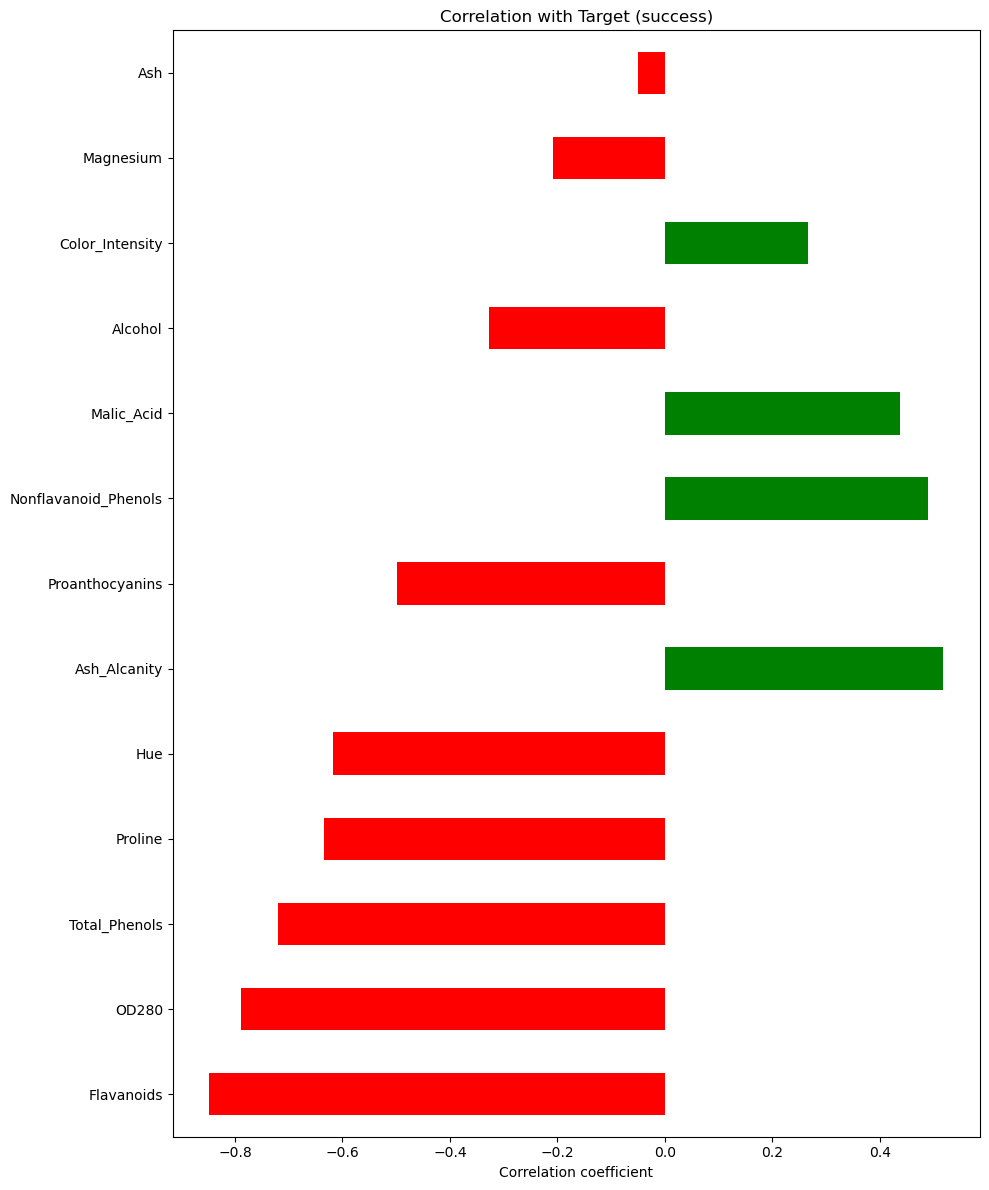

In [65]:
numeric_df = df.select_dtypes(include=[int,float])
target_corr = numeric_df.corr()['Customer_Segment'].drop('Customer_Segment').sort_values(key=abs, ascending=False)
print(target_corr)

plt.figure(figsize=(10,12))
target_corr.plot(kind='barh', color=['green' if v > 0 else 'red' for v in target_corr])
plt.title('Correlation with Target (success)')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

#### Our dataset contains only numerical features.No categorical encoding is required.

#### Define X and y

In [66]:
X=df.drop(columns=['Customer_Segment'])
y=df['Customer_Segment']

#### Train test split

In [67]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)

#### Train intial gradient boosting model

In [68]:
gb=GradientBoostingClassifier(random_state=42)

gb.fit(Xtrain,ytrain)

ypred= gb.predict(Xtest)

#### Model Evaluation

In [69]:
print(f'Training Accuracy: {gb.score(Xtrain, ytrain)}')
print(f'Testing Accuracy: {gb.score(Xtest, ytest)}')

Training Accuracy: 1.0
Testing Accuracy: 0.9444444444444444


In [70]:
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

ypred= gb.predict(Xtest)

print(classification_report(ytest,ypred))
print(confusion_matrix(ytest,ypred))

              precision    recall  f1-score   support

           1       0.93      1.00      0.97        14
           2       0.93      0.93      0.93        14
           3       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

[[14  0  0]
 [ 1 13  0]
 [ 0  1  7]]


#### On the uploaded dataset, the initial Gradient Boosting model achieved approximately:

#### Accuracy = 94.44%

### Hyperparameter Tuning

##### Since Gradient Boosting has several important hyperparameters, tuning can improve performance.

In [80]:
params={"n_estimators":[100,150,200,250],
        "learning_rate":[0.03,0.05,0.1],
        "max_depth":[4,5,6,7],
        "min_samples_split":[5,10,15,20],
        "min_samples_leaf":[1,2,4,5]}

params        

{'n_estimators': [100, 150, 200, 250],
 'learning_rate': [0.03, 0.05, 0.1],
 'max_depth': [4, 5, 6, 7],
 'min_samples_split': [5, 10, 15, 20],
 'min_samples_leaf': [1, 2, 4, 5]}

In [81]:
grid_search=GridSearchCV(GradientBoostingClassifier(random_state=42),params,verbose=1)

grid_search.fit(Xtrain,ytrain)

Fitting 5 folds for each of 768 candidates, totalling 3840 fits


GridSearchCV(estimator=GradientBoostingClassifier(random_state=42),
             param_grid={'learning_rate': [0.03, 0.05, 0.1],
                         'max_depth': [4, 5, 6, 7],
                         'min_samples_leaf': [1, 2, 4, 5],
                         'min_samples_split': [5, 10, 15, 20],
                         'n_estimators': [100, 150, 200, 250]},
             verbose=1)

#### find the best parameters

In [82]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 150}
Best CV Score:
0.9645320197044336


### Final Model

In [83]:
final_gb = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=5,
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=150,
    random_state=42
)

final_gb.fit(Xtrain, ytrain)                                  

GradientBoostingClassifier(max_depth=5, min_samples_leaf=4,
                           min_samples_split=10, n_estimators=150,
                           random_state=42)

In [85]:
print("Accuracy:", accuracy_score(ytest, ypred))

print("\nClassification Report:")
print(classification_report(ytest, ypred))

print("\nConfusion Matrix:")
print(confusion_matrix(ytest, ypred))

Accuracy: 0.9444444444444444

Classification Report:
              precision    recall  f1-score   support

           1       0.93      1.00      0.97        14
           2       0.93      0.93      0.93        14
           3       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36


Confusion Matrix:
[[14  0  0]
 [ 1 13  0]
 [ 0  1  7]]


#### Conclusion: The objective of this project was to develop a machine learning classification model capable of predicting wine/customer segments based on the chemical properties of wine.

The dataset contained 178 observations with 13 numerical chemical features and one target variable, `Customer_Segment`. During Exploratory Data Analysis and data-quality checks, no missing values or duplicate records were identified. Since all input features were numerical, categorical encoding was not required.

A Gradient Boosting Classifier was trained and its hyperparameters were optimized using GridSearchCV. The tuned model achieved a cross-validation accuracy of 96.45% and a test accuracy of 94.44%.

The classification report showed balanced performance across the three classes, with a macro F1-score of approximately 0.94. The confusion matrix showed that only two observations were misclassified out of 36 test observations.

Overall, Gradient Boosting performed effectively for this multiclass classification problem and demonstrated that the chemical characteristics of wine contain strong information for distinguishing between the three customer/wine segments.